
  CONTROLLED EXPERIMENT RUN 
Group Baseline Config (C=0.01, Threshold=0.45)
Accuracy BEFORE LLM Feature: 88.59%
Accuracy AFTER LLM Feature:  88.59%
Net Absolute Change:          +0.00%

Detailed Classification Metrics After Adding LLM Feature:
               precision    recall  f1-score   support

       Normal       0.91      0.83      0.87        82
Heart Disease       0.87      0.93      0.90       102

     accuracy                           0.89       184
    macro avg       0.89      0.88      0.88       184
 weighted avg       0.89      0.89      0.89       184



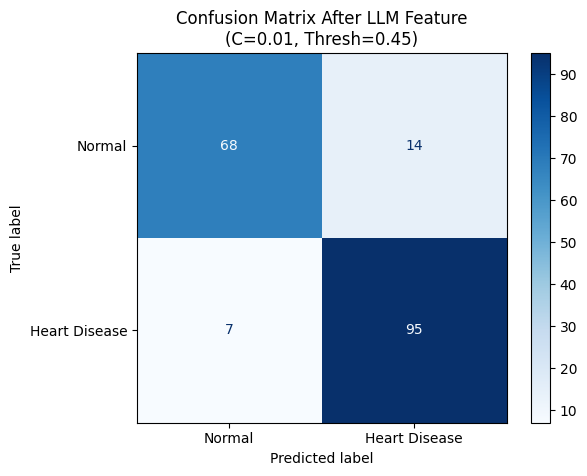

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# 1. Load data 
train = pd.read_csv("../1-Data/train_processed.csv")
x_train_before = train.drop(columns=["HeartDisease"])
y_train = train["HeartDisease"]

test = pd.read_csv("../1-Data/test_processed.csv")
x_test_before = test.drop(columns=["HeartDisease"])
y_test = test["HeartDisease"]


CHOSEN_C = 0.01
CHOSEN_THRESHOLD = 0.45

# 2. RUN EXPERIMENT BEFORE LLM FEATURE
model_before = LogisticRegression(C=CHOSEN_C, random_state=42, max_iter=1000)
model_before.fit(x_train_before, y_train)


y_proba_before = model_before.predict_proba(x_test_before)[:, 1]
y_pred_before = (y_proba_before >= CHOSEN_THRESHOLD).astype(int)
acc_before = accuracy_score(y_test, y_pred_before)


# 3. IMPLEMENT THE LLM FEATURE RECOMMENDATION
x_train_after = x_train_before.copy()
x_test_after = x_test_before.copy()


x_train_after["MaxHR_x_ExerciseAngina"] = x_train_after["MaxHR"] * x_train_after["ExerciseAngina"]
x_test_after["MaxHR_x_ExerciseAngina"] = x_test_after["MaxHR"] * x_test_after["ExerciseAngina"]


# 4. RUN EXPERIMENT AFTER LLM FEATURE
model_after = LogisticRegression(C=CHOSEN_C, random_state=42, max_iter=1000)
model_after.fit(x_train_after, y_train)


y_proba_after = model_after.predict_proba(x_test_after)[:, 1]
y_pred_after = (y_proba_after >= CHOSEN_THRESHOLD).astype(int)
acc_after = accuracy_score(y_test, y_pred_after)



print("\n=========================================================")
print("  CONTROLLED EXPERIMENT RUN ")
print("=========================================================")
print(f"Group Baseline Config (C={CHOSEN_C}, Threshold={CHOSEN_THRESHOLD})")
print(f"Accuracy BEFORE LLM Feature: {acc_before * 100:.2f}%")
print(f"Accuracy AFTER LLM Feature:  {acc_after * 100:.2f}%")
print(f"Net Absolute Change:          {((acc_after - acc_before) * 100):+.2f}%")
print("=========================================================")

print("\nDetailed Classification Metrics After Adding LLM Feature:")
print(classification_report(y_test, y_pred_after, target_names=["Normal", "Heart Disease"]))


cm_after = confusion_matrix(y_test, y_pred_after)
display = ConfusionMatrixDisplay(confusion_matrix=cm_after, display_labels=["Normal", "Heart Disease"])
display.plot(cmap="Blues")
plt.title(f"Confusion Matrix After LLM Feature\n(C={CHOSEN_C}, Thresh={CHOSEN_THRESHOLD})")
plt.show()